## Setup

In [2]:
import sys, os
sys.path.append(os.path.abspath('..'))

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import load_file_joined, ca, ca_moyenne_mobile, plot_lorenz, load_all_clients

#### Config

In [4]:
sns.set_theme(
    palette='Set2'
)

plt.rcParams.update({
    "font.family": "Trebuchet MS",
    "font.weight": "bold",
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10
})

In [5]:
df = load_file_joined()
df.head()

,id_prod,date,session_id,client_id,sex,birth,price,categ
0,0_1259,2021-03-01 00:01:07.843138,s_1,c_329,f,1967,11.99,0
1,0_1390,2021-03-01 00:02:26.047414,s_2,c_664,m,1960,19.37,0
2,0_1352,2021-03-01 00:02:38.311413,s_3,c_580,m,1988,4.50,0
3,0_1458,2021-03-01 00:04:54.559692,s_4,c_7912,f,1989,6.55,0
4,0_1358,2021-03-01 00:05:18.801198,s_5,c_2033,f,1956,16.49,0


#### Ajouter une colonne "âge"

In [6]:
df['age'] = df.date.dt.year - df.birth

## CA

### CA par client

In [7]:
ca_par_client = ca(
    df=df,
    targetCol='client_id',
    amountCol='price'
)
ca_par_client.price = ca_par_client.price.round(2)
ca_par_client.head()

,client_id,price
677,c_1609,326039.89
4388,c_4958,290227.03
6337,c_6714,153918.60
2724,c_3454,114110.57
634,c_1570,5285.82


> Un saut significatif est observé entre le 4ème client (114k€) et le 5ème (5k€), suggérant que les 4 premiers clients sont des professionnels (B2B).

#### Définir B2B et B2C

In [8]:
# biggest business
clients_b2b = ca_par_client.client_id.head(4).tolist()
df['segment_client'] = df.client_id.apply(lambda x: 'B2B' if x in clients_b2b else 'B2C')


In [9]:
df_b2b = df.loc[df.segment_client == 'B2B']
df_b2c = df.loc[df.segment_client == 'B2C']

#### Export data

In [10]:
# df_b2b.to_csv('clients_b2b.csv', index=False)
# df_b2c.to_csv('clients_b2c.csv', index=False)
# df.to_csv('all_clients.csv', index=False)

### La moyenne mobile

#### Global

In [11]:
df_ca = ca_moyenne_mobile(
    df=df,
    col_ca='price'
)

#### Graphique donut

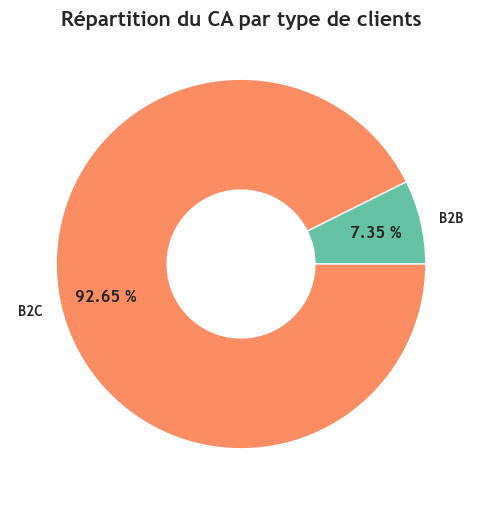

In [12]:
part_clients = df.groupby('segment_client')['price'].sum().reset_index()

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    part_clients.price,
    labels=part_clients.segment_client,
    autopct='%.2f %%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

ax.set_title("Répartition du CA par type de clients")
plt.show()

#### Clients B2B 

In [13]:
df_ca_b2b = ca_moyenne_mobile(
    df=df_b2b,
    col_ca='price'
)
df_ca_b2b

,date,ca,mm_7,mm_30
0,2021-03-01,1096.57,NaN,NaN
1,2021-03-02,927.98,NaN,NaN
2,2021-03-03,1298.70,NaN,NaN
3,2021-03-04,1628.45,NaN,NaN
4,2021-03-05,1255.28,NaN,NaN
...,...,...,...,...
725,2023-02-24,1299.05,1264.270000,1245.737000
726,2023-02-25,1199.95,1175.547143,1252.392667
727,2023-02-26,1104.87,1193.761429,1238.617667
728,2023-02-27,1194.74,1167.858571,1256.100333


#### Clients B2C

In [14]:
df_ca_b2c = ca_moyenne_mobile(
    df=df_b2c,
    col_ca='price'
)
df_ca_b2c

,date,ca,mm_7,mm_30
0,2021-03-01,15468.65,NaN,NaN
1,2021-03-02,14558.47,NaN,NaN
2,2021-03-03,13899.99,NaN,NaN
3,2021-03-04,13567.62,NaN,NaN
4,2021-03-05,16216.09,NaN,NaN
...,...,...,...,...
725,2023-02-24,13908.84,15224.508571,14992.633333
726,2023-02-25,14561.30,14831.200000,14935.675667
727,2023-02-26,15199.85,14841.260000,14923.826667
728,2023-02-27,17976.07,15319.711429,15026.267667


#### Graphique 

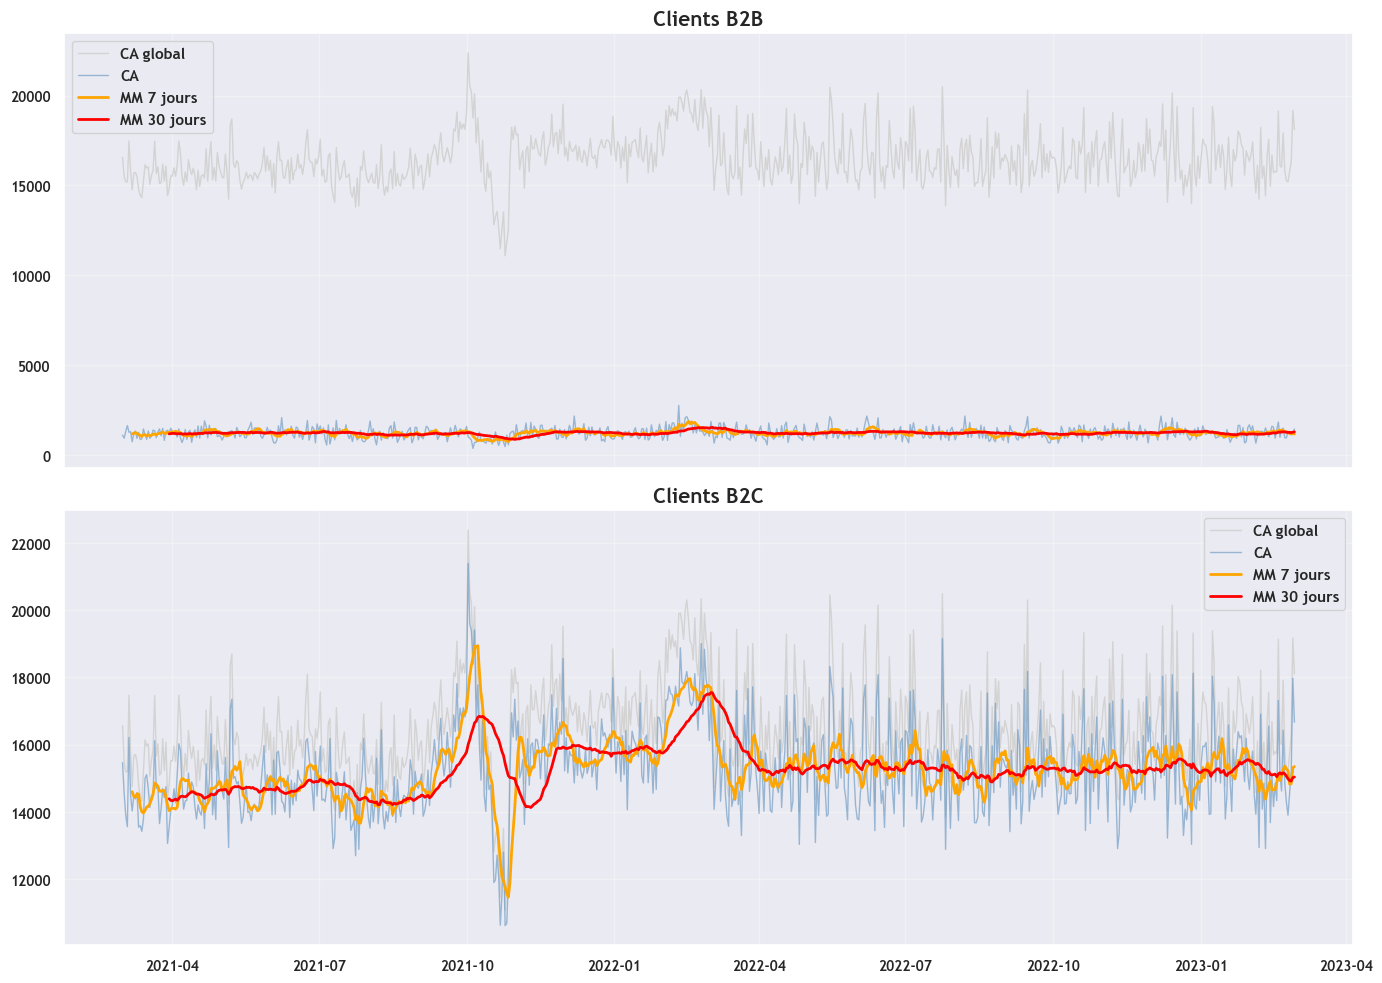

In [15]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

for ax, ca_segment, titre in [
    (ax1, df_ca_b2b, 'Clients B2B'),
    (ax2, df_ca_b2c, 'Clients B2C')
]:
    # CA global en arrière-plan
    ax.plot(df_ca.date, df_ca.ca, color='lightgray', linewidth=1, label='CA global')
    
    # CA du segment
    ax.plot(ca_segment.date, ca_segment.ca, color='steelblue', linewidth=1, alpha=0.5, label='CA')
    
    # moyennes mobiles
    ax.plot(ca_segment.date, ca_segment['mm_7'], color='orange', linewidth=2, label='MM 7 jours')
    ax.plot(ca_segment.date, ca_segment['mm_30'], color='red', linewidth=2, label='MM 30 jours')
    
    ax.set_title(titre)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### CA par catégorie

In [16]:
ca_par_categ = ca(
    df=df,
    targetCol='categ',
    amountCol='price'
)
ca_par_categ.price = ca_par_categ.price.round(2)
ca_par_categ.head()

,categ,price
1,1,4827657.11
0,0,4419730.97
2,2,2780275.02


#### Graphique donut

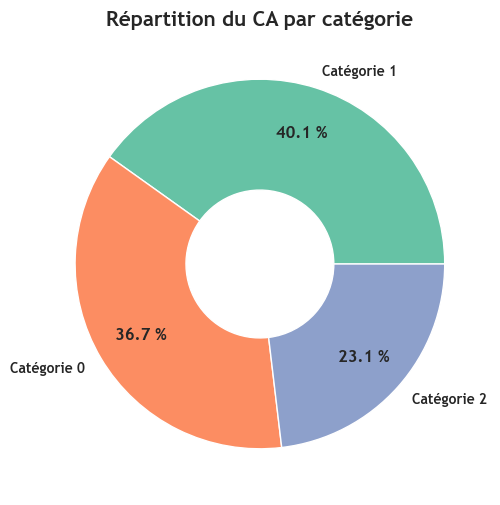

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    ca_par_categ.price,
    labels=[ 'Catégorie ' + str(cat) for cat in ca_par_categ.categ ],
    autopct='%.1f %%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

ax.set_title("Répartition du CA par catégorie")
plt.show()

### Nb de clients/transactions/produits par mois

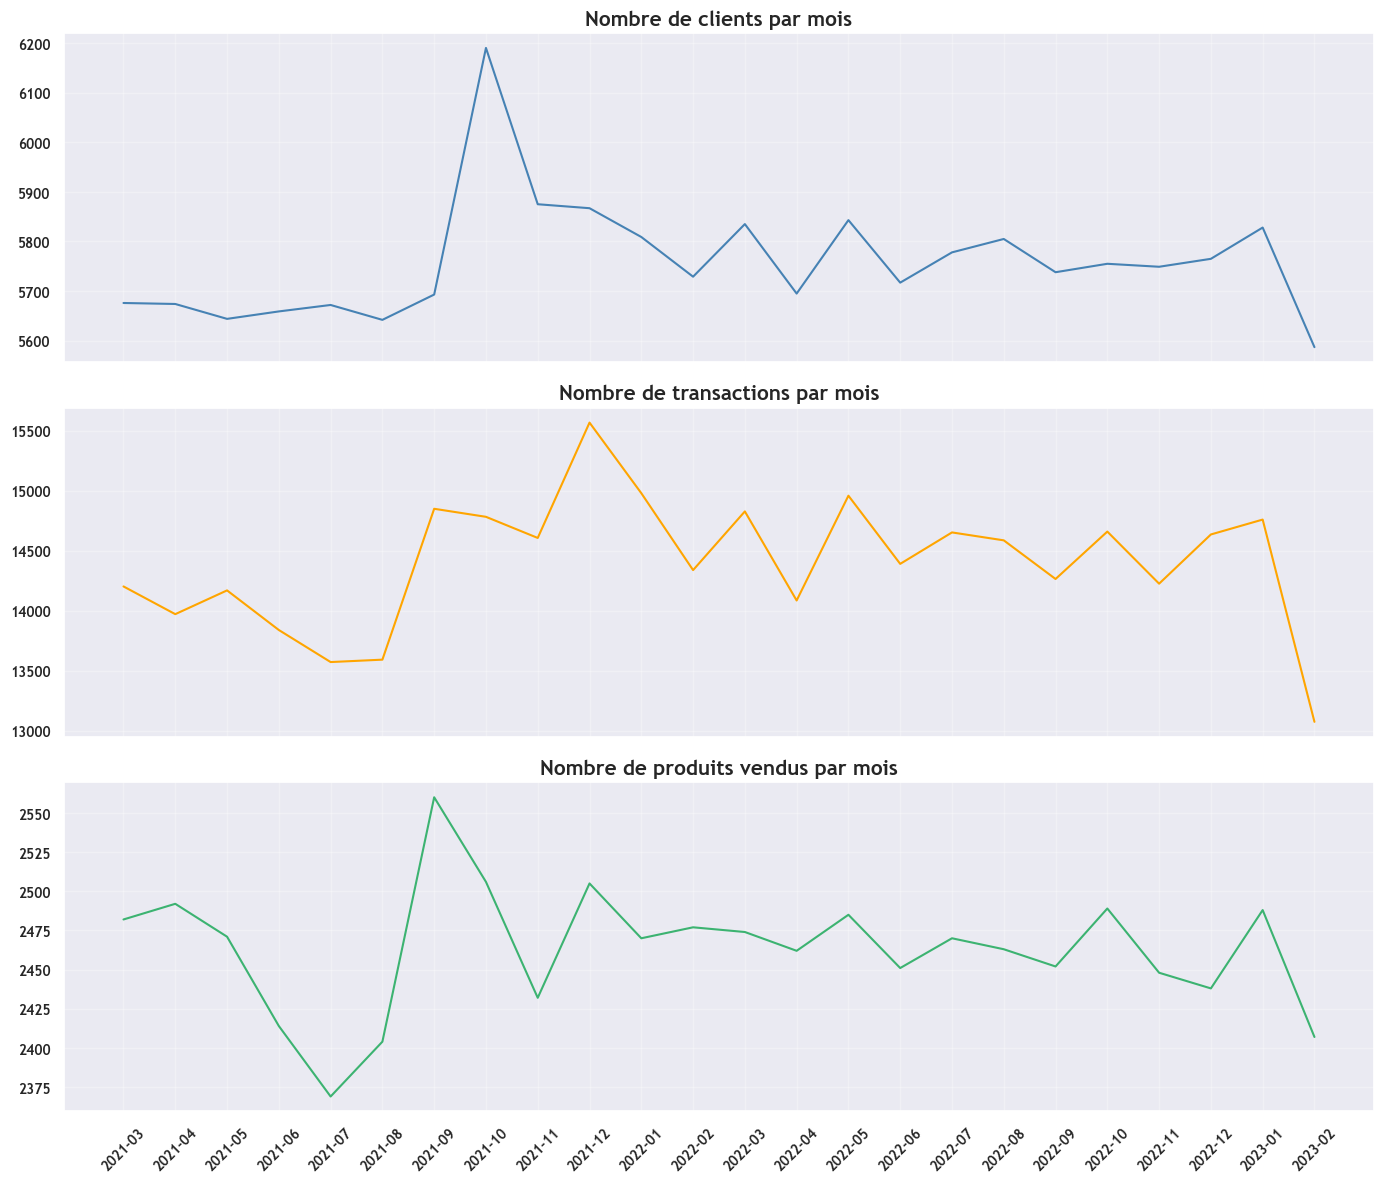

In [18]:
df_by_month = df.copy()
df_by_month['month'] = df_by_month.date.dt.to_period('M')

nb_clients = df_by_month.groupby('month')['client_id'].nunique()
nb_transactions = df_by_month.groupby('month')['session_id'].nunique()
nb_products = df_by_month.groupby('month')['id_prod'].nunique()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, data, title, colour in [
    (ax1, nb_clients, "Nombre de clients par mois", 'steelblue'),
    (ax2, nb_transactions, "Nombre de transactions par mois", 'orange'),
    (ax3, nb_products, "Nombre de produits vendus par mois", 'mediumseagreen')
]:
    ax.plot(
        data.index.astype(str),
        data.values,
    color=colour
    )
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

### Les tops / Les flops

In [19]:
# par CA
ca_by_product = df.groupby('id_prod')['price'].sum().sort_values(ascending=False)
top10_ca = ca_by_product.head(10)
flop10_ca = ca_by_product.tail(10).sort_values()

# par quantité
quantity_by_product = df.groupby('id_prod').size().sort_values(ascending=False)
top10_quantity = quantity_by_product.head(10)
flop10_quantity = quantity_by_product.tail(10).sort_values()

#### Graphique

In [20]:
def make_lollipop(data, title, colour, xlabel, fmt='ca'):
    fig = plt.figure(figsize=(10, 6))
    plt.hlines(y=data.index, xmin=0, xmax=data.values, color=colour, linewidth=2)
    plt.plot(data.values, data.index, 'o', color=colour, markersize=8)

    for value, label in zip(data.values, data.index):
        if fmt == 'ca':
            pct = f' {value:,.0f} €'
        else:
            pct = f' {value:,.0f}'
        plt.text(value*1.03, label, pct, va='center', fontsize=10, color=colour)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel("Produit ID")
    plt.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

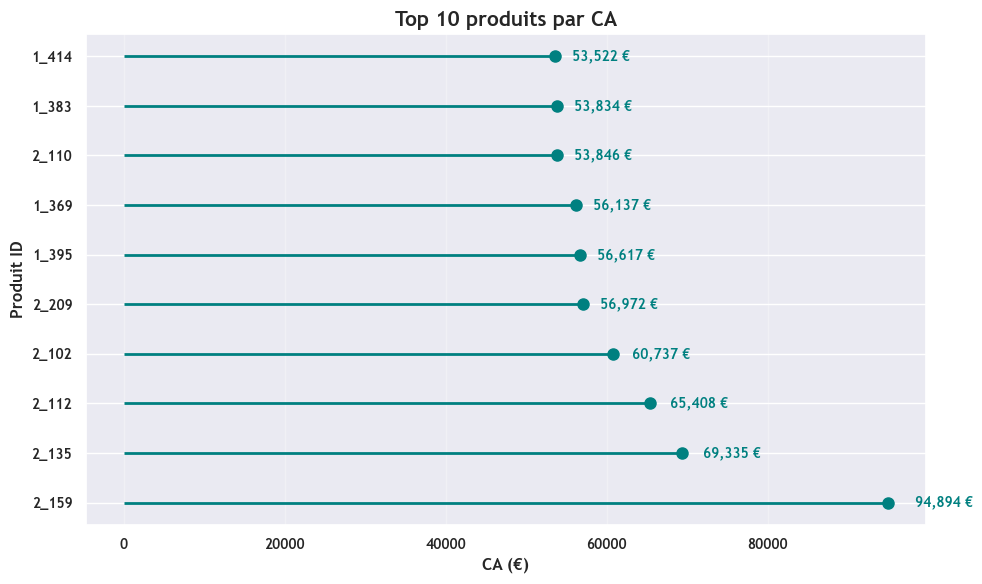

In [21]:
make_lollipop(
    top10_ca,
    "Top 10 produits par CA",
    colour='teal',
    xlabel="CA (€)"
)

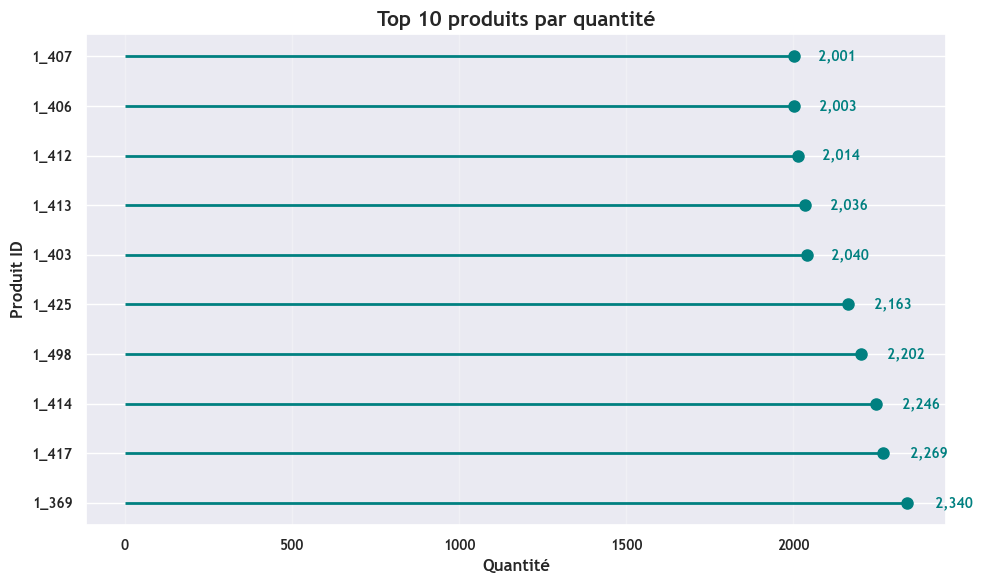

In [22]:
make_lollipop(
    top10_quantity,
    "Top 10 produits par quantité",
    'teal',
    xlabel="Quantité",
    fmt=""
)

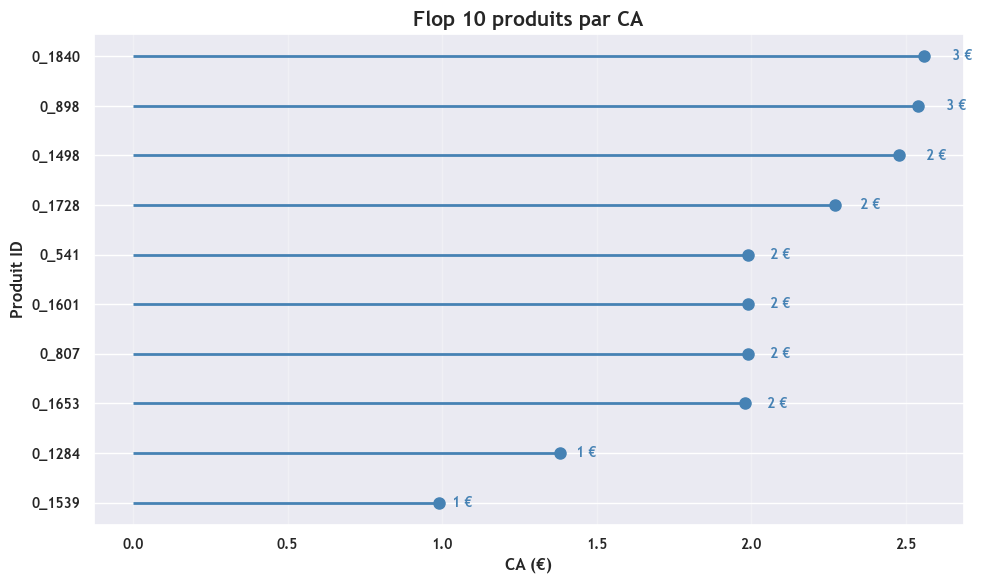

In [23]:
make_lollipop(
    flop10_ca,
    "Flop 10 produits par CA",
    colour='steelblue',
    xlabel="CA (€)"
)

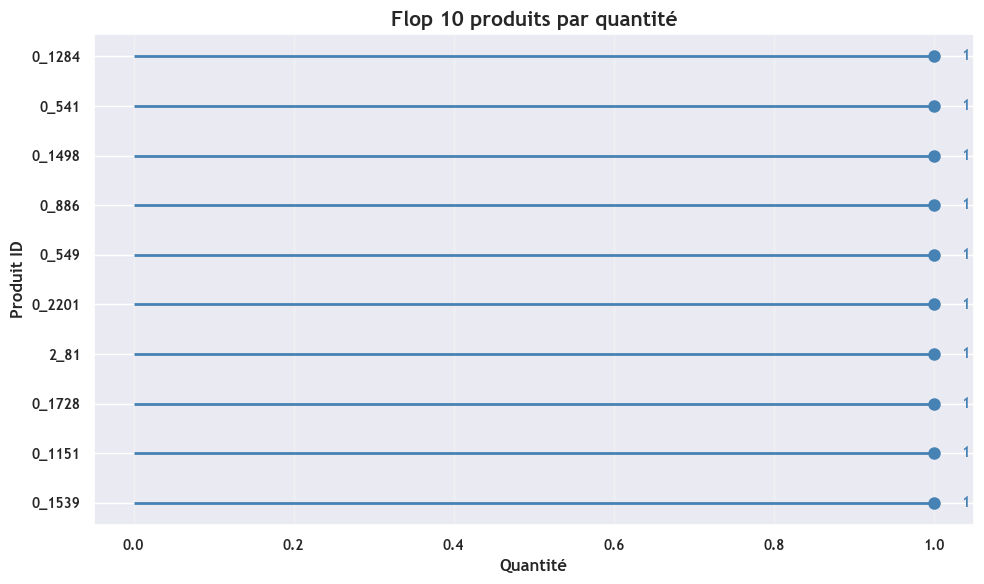

In [24]:
make_lollipop(
    flop10_quantity,
    "Flop 10 produits par quantité",
    'steelblue',
    xlabel="Quantité",
    fmt=""
)

#### Distribution du nombre de ventes par produit

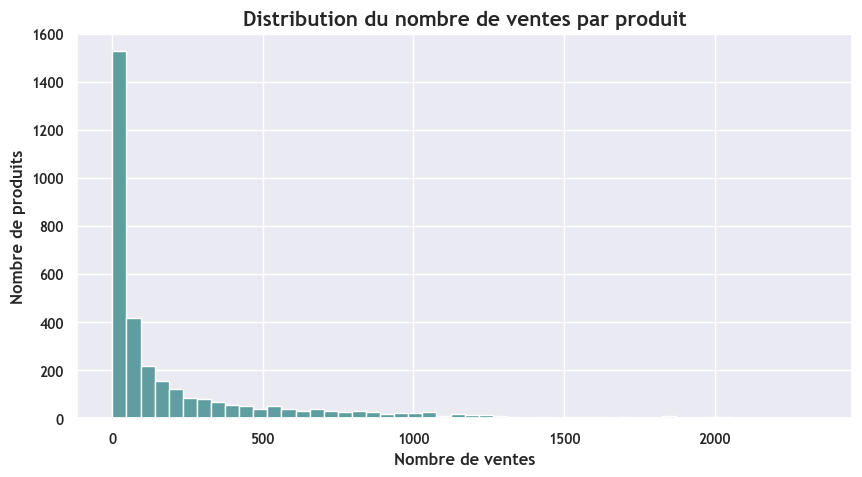

In [25]:
quantity_by_product.hist(
    bins=50,
    figsize=(10, 5), 
    color='cadetblue'
)
plt.title('Distribution du nombre de ventes par produit')
plt.xlabel('Nombre de ventes')
plt.ylabel('Nombre de produits')
plt.show()

#### Positionnement des produits
- Les produits stars (top CA et top quantité) appartiennent tous à la catégorie 1.
- Les produits chers & rares génèrent un CA élevé malgré peu de ventes (prix unitaire élevé).
- Les produits populaires & pas chers nécessitent un volume important pour compenser leur faible marge.

In [26]:
top_ca = set(top10_ca.index)
top_quantity = set(top10_quantity.index)

stars = top_ca & top_quantity
cher_rare = top_ca - top_quantity
populaire_pas_cher = top_quantity - top_ca

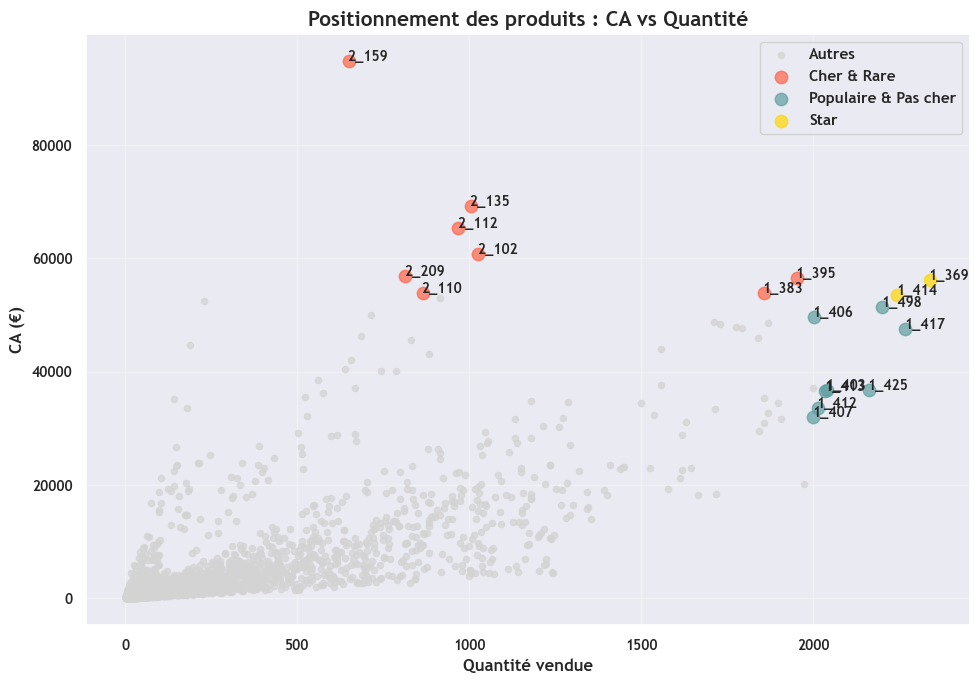

In [27]:
df_products = pd.DataFrame({
    'ca': df.groupby('id_prod')['price'].sum(),
    'quantity': df.groupby('id_prod').size()
})

# assigner une catégorie à chaque produit
def categorise(prod):
    if prod in stars:
        return 'Star'
    elif prod in cher_rare:
        return 'Cher & Rare'
    elif prod in populaire_pas_cher:
        return 'Populaire & Pas cher'
    else:
        return 'Autres'
    
df_products['categorie'] = df_products.index.map(categorise)
colors = {
    'Star': 'gold',
    'Cher & Rare': 'tomato',
    'Populaire & Pas cher': 'cadetblue',
    'Autres': 'lightgray'
}

fig, ax = plt.subplots(figsize=(10, 7))

for cat, group in df_products.groupby('categorie'):
    ax.scatter(
        group['quantity'], 
        group['ca'],
        label=cat,
        color=colors[cat],
        alpha=0.7,
        s=80 if cat != 'Autres' else 20
    )
for prod, row in df_products[df_products['categorie'] != 'Autres'].iterrows():
    ax.annotate(
        prod,
        xy=(row['quantity'], row['ca']),
        xytext=(-1, 0),  # offset
        textcoords='offset points',
        fontsize=10
    )

ax.set_xlabel('Quantité vendue')
ax.set_ylabel('CA (€)')
ax.set_title('Positionnement des produits : CA vs Quantité')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### B2B

#### Summary

In [28]:
ca_total = df.price.sum()

analyse_b2b = df_b2b.groupby('client_id').agg({ 'price': 'sum', 'session_id': 'nunique' }).reset_index()
analyse_b2b.columns = ['client_id', 'ca_total', 'nb_transactions']

ca_total_b2b = analyse_b2b['ca_total'].sum()  
analyse_b2b['ca_total'] = analyse_b2b['ca_total'].round(2)
analyse_b2b['pct_ca_b2b_%'] = (analyse_b2b.ca_total / ca_total_b2b * 100).round(2)
analyse_b2b['pct_ca_global_%'] = (analyse_b2b.ca_total / ca_total * 100).round(2)

analyse_b2b = analyse_b2b.sort_values(by='pct_ca_b2b_%', ascending=False).reset_index(drop=True)
analyse_b2b

,client_id,ca_total,nb_transactions,pct_ca_b2b_%,pct_ca_global_%
0,c_1609,326039.89,10997,36.87,2.71
1,c_4958,290227.03,3851,32.82,2.41
2,c_6714,153918.60,2620,17.41,1.28
3,c_3454,114110.57,5571,12.90,0.95


##### Graphique donut

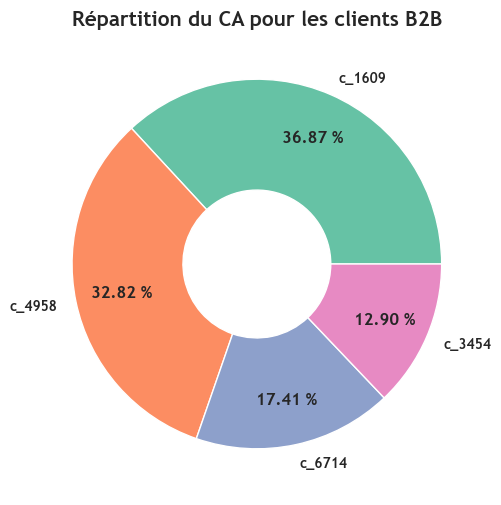

In [29]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    analyse_b2b['pct_ca_b2b_%'],
    labels=analyse_b2b.client_id,
    autopct='%.2f %%',
    pctdistance=0.75,
    wedgeprops=dict(width=0.6)
)

ax.set_title("Répartition du CA pour les clients B2B")
plt.show()

#### Par catégorie

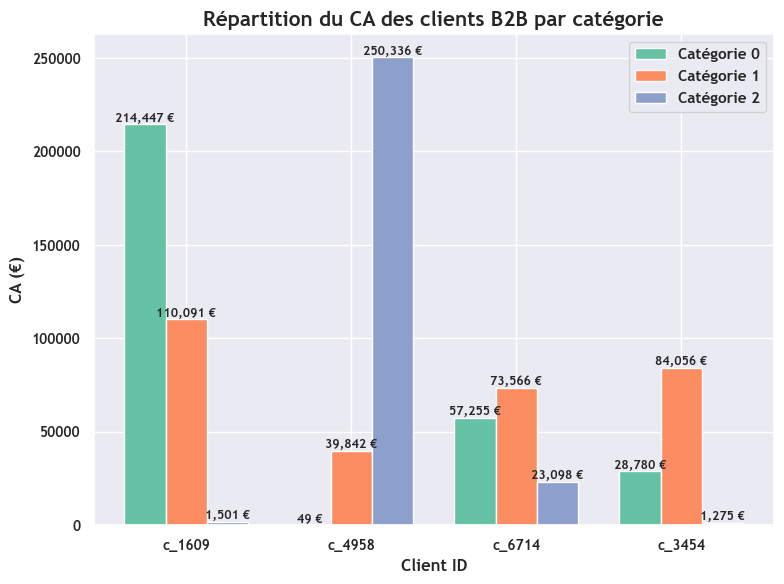

In [30]:
# unstack() melts "categ" column into different columns
ca_b2b_categ = df_b2b.groupby(['client_id', 'categ'])['price'].sum().round(2).unstack()
ca_b2b_categ['sum'] = ca_b2b_categ.sum(axis=1)
ca_b2b_categ.sort_values(by='sum', ascending=False, inplace=True)

x = np.arange(len(ca_b2b_categ.index))
width = 0.25

fig, ax = plt.subplots(figsize=(8, 6))

for index, categ in enumerate(ca_b2b_categ.columns):
    if categ == 'sum':
        break
    bars = ax.bar(
        x+index*width,
        ca_b2b_categ[categ],
        width,
        label=f"Catégorie {categ}"
    )

    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:,.0f} €',
            ha='center', 
            va='bottom', 
            fontsize=9
        )

plt.xticks(x + width)
ax.set_xticklabels(ca_b2b_categ.index)
plt.xlabel("Client ID")
plt.ylabel("CA (€)")
plt.title("Répartition du CA des clients B2B par catégorie")
plt.legend()
plt.tight_layout()
plt.show()


### Courbe de Lorenz
Gini = 0.442 —> distribution modérément inégale.  
Les 4 clients B2B représentent ~7.35% du CA global malgré leur faible nombre.

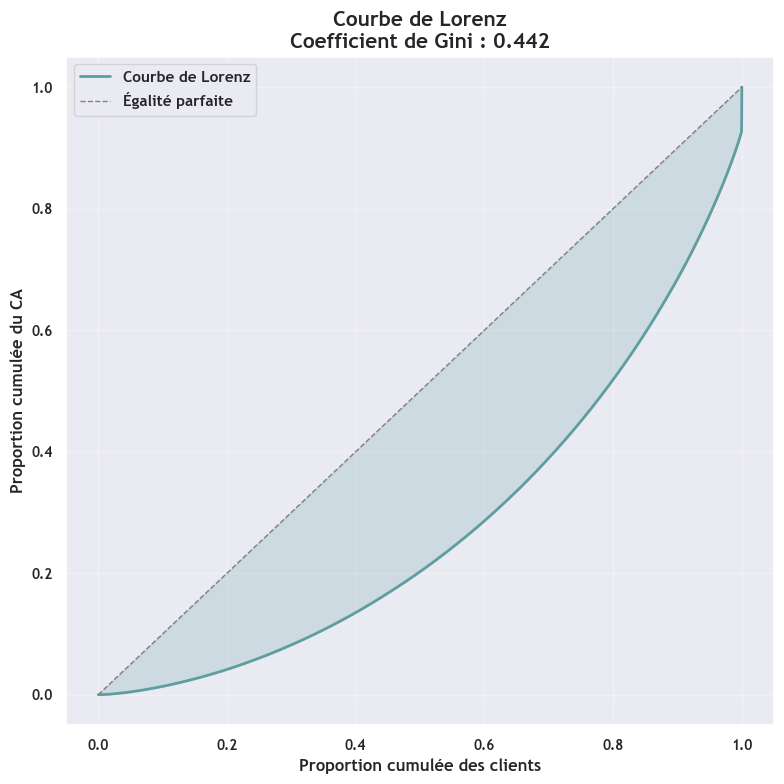

In [31]:
ax, gini = plot_lorenz(
    df=df,
    targetCol='client_id',
    amountCol='price'
)

ax.set_title(f'Courbe de Lorenz\nCoefficient de Gini : {gini:.3f}')
ax.set_xlabel('Proportion cumulée des clients')
ax.set_ylabel('Proportion cumulée du CA')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
